In [30]:
import pandas as pd
import seaborn as sns
import numpy as np
nhane = pd.read_csv('my_nhane.csv')
days = pd.DataFrame({'date':pd.date_range('2017-01-01','2019-12-31',freq='D')})
date = days.sample(n=nhane.shape[0],replace=True)
date = date.reset_index()
date.drop(columns='index',inplace=True)
nhane['interview_day'] = date

性别,男性,女性
周区间,,
2016-12-26/2017-01-01,7.57,8.08
2017-01-02/2017-01-08,27.21,15.62
2017-01-09/2017-01-15,10.37,13.61
2017-01-16/2017-01-22,10.03,18.16
2017-01-23/2017-01-29,12.35,9.48
2017-01-30/2017-02-05,10.76,10.55
2017-02-06/2017-02-12,11.29,20.49
2017-02-13/2017-02-19,13.97,13.02
2017-02-20/2017-02-26,12.21,18.63


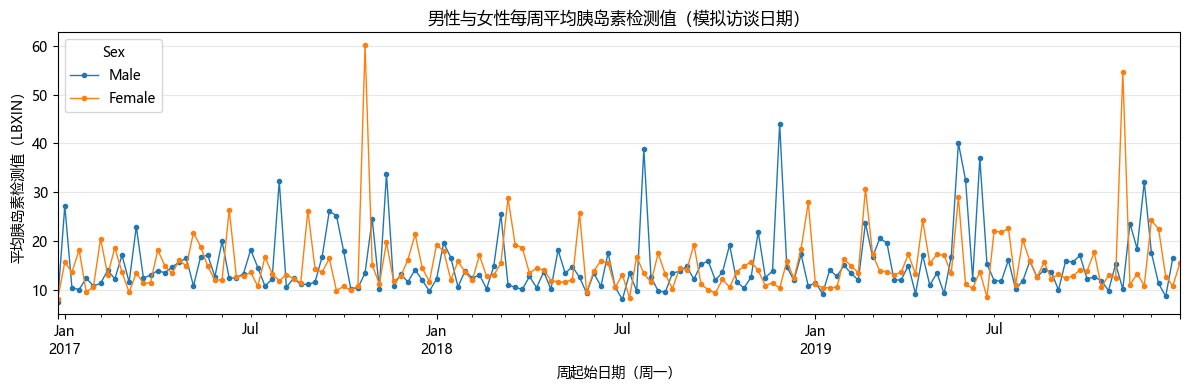

In [2]:
import matplotlib.pyplot as plt
from IPython.display import display

analysis_data = nhane.copy()

analysis_data['interview_day'] = pd.to_datetime(
    analysis_data['interview_day'], errors='coerce'
)
analysis_data['LBXIN'] = pd.to_numeric(analysis_data['LBXIN'], errors='coerce')
analysis_data = analysis_data.loc[
    analysis_data['RIAGENDR'].isin(['Male', 'Female'])
].dropna(subset=['interview_day', 'LBXIN'])

analysis_data['week'] = analysis_data['interview_day'].dt.to_period('W-SUN')
weekly_insulin = (
    analysis_data.groupby(['week', 'RIAGENDR'])['LBXIN']
    .mean()
    .unstack('RIAGENDR')
    .reindex(columns=['Male', 'Female'])
    .sort_index()
)

with pd.option_context('display.max_rows', None):
    display(
        weekly_insulin.rename(columns={'Male': '男性', 'Female': '女性'})
        .rename_axis(index='周区间', columns='性别')
        .round(2)
    )

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plot_data = weekly_insulin.copy()
plot_data.index = plot_data.index.start_time
ax = plot_data.plot(figsize=(12, 4), marker='.', linewidth=1)
ax.set(
    title='男性与女性每周平均胰岛素检测值（模拟访谈日期）',
    xlabel='周起始日期（周一）',
    ylabel='平均胰岛素检测值（LBXIN）'
)
ax.legend(title='Sex')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
nhane.head()

,Unnamed: 0,SEQN,BPQ080,BPQ100D,BMDSTATS,BMXHT,BMXBMI,BMDBMIC,BMXLEG,BMXWAIST,...,DIQ070,CDQ010,ALQ151,OCQ180,LUAXSTAT,LUXCAPM,LBXIN,MCQ053,LBXTC,interview_day
0,1,109263,NaN,NaN,No body measures exam data,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,2018-09-28
1,2,109264,NaN,NaN,Complete data for age group,154.7,17.6,Normal weight,36.3,63.8,...,NaN,NaN,NaN,NaN,Ineligible,NaN,6.05,No,166.0,2019-03-05
2,3,109265,NaN,NaN,Complete data for age group,89.3,15.0,Normal weight,NaN,41.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,2017-11-03
3,4,109266,Yes,NaN,Complete data for age group,160.2,37.8,NaN,40.8,117.9,...,No,NaN,No,40.0,Complete,277.0,NaN,No,195.0,2017-02-10
4,5,109267,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,40.0,NaN,NaN,NaN,No,NaN,2019-02-20


In [33]:
nhane[['SEQN','BMXBMI','RIDSTATR','RIDRETH1','BMXHT']].head()

,SEQN,BMXBMI,RIDSTATR,RIDRETH1,BMXHT
0,109263,NaN,Both interviewed and MEC examined,Other Race - Including Multi-Racial,NaN
1,109264,17.6,Both interviewed and MEC examined,Mexican American,154.7
2,109265,15.0,Both interviewed and MEC examined,Non-Hispanic White,89.3
3,109266,37.8,Both interviewed and MEC examined,Other Race - Including Multi-Racial,160.2
4,109267,NaN,Interviewed only,Other Hispanic,NaN


In [34]:
# nhane.shape

# nhane['BMDBMIC']
# nhane[['BMDBMIC','SEQN']]

# nhane.loc[999]
# nhane.loc[:, 'BMDBMIC']
# nhane.loc[3:5, 'BMDBMIC']
# nhane.head(12)

# nhane.loc[list(range(4)) + [8], ['BMDBMIC', 'SEQN']]
# nhane.loc[[1,3,5], 'SEQN':'BMDBMIC']

In [35]:
# nhane.loc[25, 'BMXHT'] = 200
# nhane.loc[25, ['BMDBMIC', 'BMXHT']]
# nhane.iloc[0:3, 2]
# nhane.iloc[[1,2,3], [4,5,6]]
nhane.iloc[list(range(10, 81)) + [90], [4,5,6]]

,BMDSTATS,BMXHT,BMXBMI
10,Complete data for age group,184.2,21.9
11,Complete data for age group,185.3,30.2
12,Partial: Only height and weight obtained,120.4,14.4
13,Complete data for age group,NaN,NaN
14,Complete data for age group,162.0,18.6
...,...,...,...
77,Complete data for age group,172.9,46.2
78,Complete data for age group,125.4,15.8
79,Complete data for age group,161.0,35.5
80,NaN,NaN,NaN


In [36]:
tmp = nhane.loc[1:8, ['SEQN','BMXBMI','RIDSTATR','RIDRETH1','BMXLEG','BMXWAIST']]
tmp = tmp.set_axis(['A','B','C','D','E','F','G','H'], axis='index',)
tmp

tmp.loc[['G', 'H']]

,SEQN,BMXBMI,RIDSTATR,RIDRETH1,BMXLEG,BMXWAIST
G,109270,30.9,Both interviewed and MEC examined,Non-Hispanic Black,42.6,91.4
H,109271,29.7,Both interviewed and MEC examined,Non-Hispanic White,40.1,120.4


In [37]:
nhane['BMXBMI'] > 25
nhane[nhane['BMXBMI'] > 25]

nhane['RIDRETH1'] == 'Non-Hispanic White'
nhane[nhane['RIDRETH1'] == 'Non-Hispanic White']

nhane[(nhane['BMXBMI'] >= 18.5) & (nhane['BMXBMI'] <= 24.9)]

nhane[nhane['BMXBMI'].isna()]
nhane['RIDSTATR'].unique()

<StringArray>
['Both interviewed and MEC examined', 'Interviewed only']
Length: 2, dtype: str

In [38]:
nhane.info()

<class 'pandas.DataFrame'>
RangeIndex: 15582 entries, 0 to 15581
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Unnamed: 0     15582 non-null  int64         
 1   SEQN           15582 non-null  int64         
 2   BPQ080         10207 non-null  str           
 3   BPQ100D        2751 non-null   str           
 4   BMDSTATS       14321 non-null  str           
 5   BMXHT          13177 non-null  float64       
 6   BMXBMI         13157 non-null  float64       
 7   BMDBMIC        4758 non-null   str           
 8   BMXLEG         10996 non-null  float64       
 9   BMXWAIST       12593 non-null  float64       
 10  RIDSTATR       15582 non-null  str           
 11  RIAGENDR       15582 non-null  str           
 12  RIDAGEYR       15582 non-null  int64         
 13  RIDRETH1       15582 non-null  str           
 14  RIDRETH3       15582 non-null  str           
 15  RIDEXMON       14321 non-null 

In [39]:
nhane['BMDSTATS'].value_counts()
nhane['BMDSTATS'].isnull()
nhane['BMDSTATS'].isna()

nhane[nhane['BMDSTATS'].isnull()]['BMDSTATS']

4        NaN
5        NaN
20       NaN
36       NaN
48       NaN
        ... 
15488    NaN
15497    NaN
15532    NaN
15545    NaN
15568    NaN
Name: BMDSTATS, Length: 1261, dtype: str

In [40]:
nhane['interview_day'] = pd.to_datetime(nhane['interview_day'])

nhane['Day'] = nhane['interview_day'].dt.day
nhane['Month'] = nhane['interview_day'].dt.month
nhane['Year'] = nhane['interview_day'].dt.year
nhane['Dayname'] = nhane['interview_day'].dt.day_name()
nhane['Day_week'] = nhane['interview_day'].dt.day_of_week

nhane['Day'] = nhane['interview_day'].dt.day

nhane[['SEQN','interview_day','Day','Month','Dayname','Day_week']]

,SEQN,interview_day,Day,Month,Dayname,Day_week
0,109263,2018-09-28,28,9,Friday,4
1,109264,2019-03-05,5,3,Tuesday,1
2,109265,2017-11-03,3,11,Friday,4
3,109266,2017-02-10,10,2,Friday,4
4,109267,2019-02-20,20,2,Wednesday,2
...,...,...,...,...,...,...
15577,115983,2018-04-24,24,4,Tuesday,1
15578,115984,2017-05-07,7,5,Sunday,6
15579,115985,2018-05-20,20,5,Sunday,6
15580,115986,2019-05-23,23,5,Thursday,3


In [41]:
nhane['daydiff'] = nhane['interview_day'].diff()
nhane['daydiff'].head()
nhane[['interview_day','daydiff']].head()

,interview_day,daydiff
0,2018-09-28,NaT
1,2019-03-05,158 days
2,2017-11-03,-487 days
3,2017-02-10,-266 days
4,2019-02-20,740 days


In [42]:
nhane['daydiff'].dt.days<5
nhane[nhane['daydiff'].dt.days<5]['interview_day']

2       2017-11-03
3       2017-02-10
5       2018-12-09
6       2018-11-19
7       2017-11-30
           ...    
15573   2019-03-27
15575   2018-07-14
15576   2017-03-01
15578   2017-05-07
15581   2018-10-06
Name: interview_day, Length: 7851, dtype: datetime64[us]

In [43]:
k = nhane['interview_day'].between('2017-02-15', '2018-01-15')
nhane[k]

,Unnamed: 0,SEQN,BPQ080,BPQ100D,BMDSTATS,BMXHT,BMXBMI,BMDBMIC,BMXLEG,BMXWAIST,...,LBXIN,MCQ053,LBXTC,interview_day,Day,Month,Year,Dayname,Day_week,daydiff
2,3,109265,NaN,NaN,Complete data for age group,89.3,15.0,Normal weight,NaN,41.2,...,NaN,No,NaN,2017-11-03,3,11,2017,Friday,4,-487 days
7,8,109270,NaN,NaN,Complete data for age group,156.0,30.9,Obese,42.6,91.4,...,NaN,Yes,103.0,2017-11-30,30,11,2017,Thursday,3,-354 days
8,9,109271,Yes,Yes,Complete data for age group,182.3,29.7,NaN,40.1,120.4,...,16.96,No,147.0,2017-07-23,23,7,2017,Sunday,6,-130 days
15,16,109278,NaN,NaN,Complete data for age group,112.0,16.3,Normal weight,NaN,59.2,...,NaN,No,NaN,2017-03-10,10,3,2017,Friday,4,-894 days
19,20,109282,Yes,NaN,Other partial exam,177.1,26.6,NaN,39.0,NaN,...,7.49,Yes,233.0,2017-04-28,28,4,2017,Friday,4,-955 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15556,15557,124819,NaN,NaN,Complete data for age group,93.7,17.5,Overweight,NaN,48.4,...,NaN,No,NaN,2017-04-23,23,4,2017,Sunday,6,-616 days
15557,15558,124820,NaN,NaN,Complete data for age group,123.3,15.1,Normal weight,NaN,57.5,...,NaN,No,179.0,2017-04-18,18,4,2017,Tuesday,1,-5 days
15566,6710,115972,Yes,Yes,Complete data for age group,167.0,31.9,NaN,35.6,115.8,...,NaN,No,110.0,2017-06-12,12,6,2017,Monday,0,-664 days
15576,6720,115982,No,NaN,Complete data for age group,157.2,26.1,NaN,32.9,93.5,...,10.86,No,134.0,2017-03-01,1,3,2017,Wednesday,2,-500 days


In [44]:
nhane.tail(3)
nhane.sample(n=5)

,Unnamed: 0,SEQN,BPQ080,BPQ100D,BMDSTATS,BMXHT,BMXBMI,BMDBMIC,BMXLEG,BMXWAIST,...,LBXIN,MCQ053,LBXTC,interview_day,Day,Month,Year,Dayname,Day_week,daydiff
14873,14874,124136,No,NaN,Complete data for age group,173.9,30.3,Obese,43.0,101.8,...,NaN,No,221.0,2019-08-05,5,8,2019,Monday,0,781 days
3062,3063,112325,NaN,NaN,Complete data for age group,NaN,NaN,NaN,NaN,NaN,...,NaN,No,NaN,2019-08-23,23,8,2019,Friday,4,541 days
7146,7147,116409,NaN,NaN,Complete data for age group,102.1,14.6,Normal weight,NaN,50.0,...,NaN,No,NaN,2017-02-21,21,2,2017,Tuesday,1,-987 days
15391,15392,124654,No,NaN,Complete data for age group,173.4,24.2,Normal weight,41.5,85.1,...,NaN,No,202.0,2018-06-17,17,6,2018,Sunday,6,-45 days
10139,10140,119402,Don't know,NaN,Complete data for age group,171.1,35.2,NaN,39.0,125.9,...,67.4,No,130.0,2017-01-20,20,1,2017,Friday,4,-580 days


In [45]:
nhane.describe().T

,count,mean,min,25%,50%,75%,max,std
Unnamed: 0,15582.0,7778.99493,1.0,3896.25,7769.5,11664.75,15560.0,4488.935536
SEQN,15582.0,117040.99493,109263.0,113158.25,117031.5,120926.75,124822.0,4488.935536
BMXHT,13177.0,156.467003,78.3,151.1,162.0,171.3,199.6,22.639109
BMXBMI,13157.0,26.655362,11.9,20.4,25.8,31.4,92.3,8.41986
BMXLEG,10996.0,38.74468,24.8,36.0,38.9,41.5,55.0,4.132493
BMXWAIST,12593.0,89.659104,40.0,73.3,91.0,105.4,187.5,23.156093
RIDAGEYR,15582.0,33.735721,0.0,10.0,30.0,56.0,80.0,25.322085
OCQ180,5378.0,193.918929,5.0,31.0,40.0,46.0,99999.0,3807.572773
LUXCAPM,9708.0,257.571178,100.0,211.0,253.0,302.0,400.0,63.545593
LBXIN,4629.0,14.97919,0.71,6.31,10.18,16.61,512.5,22.838416


In [46]:
nhane.rename({'interview_day':'interview_date'}, inplace=True, axis=1)
nhane.info()

<class 'pandas.DataFrame'>
RangeIndex: 15582 entries, 0 to 15581
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   Unnamed: 0      15582 non-null  int64          
 1   SEQN            15582 non-null  int64          
 2   BPQ080          10207 non-null  str            
 3   BPQ100D         2751 non-null   str            
 4   BMDSTATS        14321 non-null  str            
 5   BMXHT           13177 non-null  float64        
 6   BMXBMI          13157 non-null  float64        
 7   BMDBMIC         4758 non-null   str            
 8   BMXLEG          10996 non-null  float64        
 9   BMXWAIST        12593 non-null  float64        
 10  RIDSTATR        15582 non-null  str            
 11  RIAGENDR        15582 non-null  str            
 12  RIDAGEYR        15582 non-null  int64          
 13  RIDRETH1        15582 non-null  str            
 14  RIDRETH3        15582 non-null  str            
 

In [47]:
nhane.sort_values('SEQN')
nhane.set_index('interview_date', inplace=True)
nhane.sort_index(inplace=True)
nhane

,Unnamed: 0,SEQN,BPQ080,BPQ100D,BMDSTATS,BMXHT,BMXBMI,BMDBMIC,BMXLEG,BMXWAIST,...,LUXCAPM,LBXIN,MCQ053,LBXTC,Day,Month,Year,Dayname,Day_week,daydiff
interview_date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,11353,120615,NaN,NaN,Complete data for age group,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,1,2017,Sunday,6,-419 days
2017-01-01,5379,114641,No,NaN,Complete data for age group,155.3,17.7,NaN,34.0,64.5,...,193.0,2.83,No,162.0,1,1,2017,Sunday,6,-272 days
2017-01-01,10058,119320,Yes,Yes,Complete data for age group,152.4,35.0,NaN,34.1,109.6,...,319.0,NaN,Yes,204.0,1,1,2017,Sunday,6,-999 days
2017-01-01,9155,118417,No,NaN,Complete data for age group,173.7,26.8,NaN,41.1,96.8,...,221.0,NaN,No,NaN,1,1,2017,Sunday,6,-690 days
2017-01-01,3333,112595,NaN,NaN,Complete data for age group,131.2,16.1,Normal weight,30.0,59.0,...,NaN,NaN,No,162.0,1,1,2017,Sunday,6,-866 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31,9919,119181,No,NaN,Complete data for age group,167.3,36.8,NaN,39.5,121.2,...,287.0,NaN,No,212.0,31,12,2019,Tuesday,1,1009 days
2019-12-31,9920,119182,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,No,NaN,31,12,2019,Tuesday,1,0 days
2019-12-31,4122,113384,No,NaN,Complete data for age group,159.6,38.1,NaN,38.1,116.8,...,240.0,20.20,No,210.0,31,12,2019,Tuesday,1,966 days


In [48]:
nhane.drop(columns = ['Unnamed: 0'], inplace=True)
nhane

,SEQN,BPQ080,BPQ100D,BMDSTATS,BMXHT,BMXBMI,BMDBMIC,BMXLEG,BMXWAIST,RIDSTATR,...,LUXCAPM,LBXIN,MCQ053,LBXTC,Day,Month,Year,Dayname,Day_week,daydiff
interview_date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,120615,NaN,NaN,Complete data for age group,NaN,NaN,NaN,NaN,NaN,Both interviewed and MEC examined,...,NaN,NaN,NaN,NaN,1,1,2017,Sunday,6,-419 days
2017-01-01,114641,No,NaN,Complete data for age group,155.3,17.7,NaN,34.0,64.5,Both interviewed and MEC examined,...,193.0,2.83,No,162.0,1,1,2017,Sunday,6,-272 days
2017-01-01,119320,Yes,Yes,Complete data for age group,152.4,35.0,NaN,34.1,109.6,Both interviewed and MEC examined,...,319.0,NaN,Yes,204.0,1,1,2017,Sunday,6,-999 days
2017-01-01,118417,No,NaN,Complete data for age group,173.7,26.8,NaN,41.1,96.8,Both interviewed and MEC examined,...,221.0,NaN,No,NaN,1,1,2017,Sunday,6,-690 days
2017-01-01,112595,NaN,NaN,Complete data for age group,131.2,16.1,Normal weight,30.0,59.0,Both interviewed and MEC examined,...,NaN,NaN,No,162.0,1,1,2017,Sunday,6,-866 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31,119181,No,NaN,Complete data for age group,167.3,36.8,NaN,39.5,121.2,Both interviewed and MEC examined,...,287.0,NaN,No,212.0,31,12,2019,Tuesday,1,1009 days
2019-12-31,119182,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Interviewed only,...,NaN,NaN,No,NaN,31,12,2019,Tuesday,1,0 days
2019-12-31,113384,No,NaN,Complete data for age group,159.6,38.1,NaN,38.1,116.8,Both interviewed and MEC examined,...,240.0,20.20,No,210.0,31,12,2019,Tuesday,1,966 days


In [49]:
cols = list(
    set(nhane.columns).difference(
        set(
            ["interview_date", "Day", "Month", "Year", "Dayname", "Day_week", "daydiff"]
        )
    )
)
print(cols)
nhane[nhane.duplicated(subset=cols)].head()


['BPQ100D', 'BPQ080', 'RIDSTATR', 'LBXIN', 'BMXLEG', 'LUXCAPM', 'SEQN', 'BMXBMI', 'RIDRETH3', 'CDQ010', 'MCQ053', 'RIAGENDR', 'BMDBMIC', 'OCQ180', 'RIDRETH1', 'BMXWAIST', 'ALQ151', 'BMXHT', 'RIDAGEYR', 'DIQ070', 'LUAXSTAT', 'RIDEXMON', 'BMDSTATS', 'LBXTC']


,SEQN,BPQ080,BPQ100D,BMDSTATS,BMXHT,BMXBMI,BMDBMIC,BMXLEG,BMXWAIST,RIDSTATR,...,LUXCAPM,LBXIN,MCQ053,LBXTC,Day,Month,Year,Dayname,Day_week,daydiff
interview_date,,,,,,,,,,,,,,,,,,,,,
2017-05-07,115984,NaN,NaN,Complete data for age group,115.9,15.9,Normal weight,NaN,55.5,Both interviewed and MEC examined,...,NaN,NaN,No,NaN,7,5,2017,Sunday,6,-352 days
2017-06-12,115972,Yes,Yes,Complete data for age group,167.0,31.9,NaN,35.6,115.8,Both interviewed and MEC examined,...,155.0,NaN,No,110.0,12,6,2017,Monday,0,-664 days
2018-03-29,115975,No,NaN,Partial: Only height and weight obtained,146.3,32.7,NaN,NaN,NaN,Both interviewed and MEC examined,...,NaN,NaN,No,NaN,29,3,2018,Thursday,3,1 days
2018-07-14,115981,NaN,NaN,Complete data for age group,164.4,21.2,Normal weight,38.2,79.4,Both interviewed and MEC examined,...,185.0,NaN,No,121.0,14,7,2018,Saturday,5,-298 days
2018-09-11,115976,No,NaN,Complete data for age group,150.1,24.5,NaN,34.5,79.4,Both interviewed and MEC examined,...,239.0,NaN,No,NaN,11,9,2018,Tuesday,1,166 days


In [50]:
nhane.drop_duplicates(subset=cols,inplace=True)
nhane

nhane[['BMXBMI',"BMXLEG",'BMXWAIST','BMXHT']].describe().T

,count,mean,std,min,25%,50%,75%,max
BMXBMI,13137.0,26.656847,8.419842,11.9,20.4,25.8,31.4,92.3
BMXLEG,10984.0,38.745666,4.132524,24.8,36.0,38.9,41.5,55.0
BMXWAIST,12574.0,89.669135,23.150206,40.0,73.3,91.0,105.4,187.5
BMXHT,13157.0,156.490188,22.621413,78.3,151.1,162.1,171.3,199.6


<Axes: xlabel='BMXBMI', ylabel='Count'>

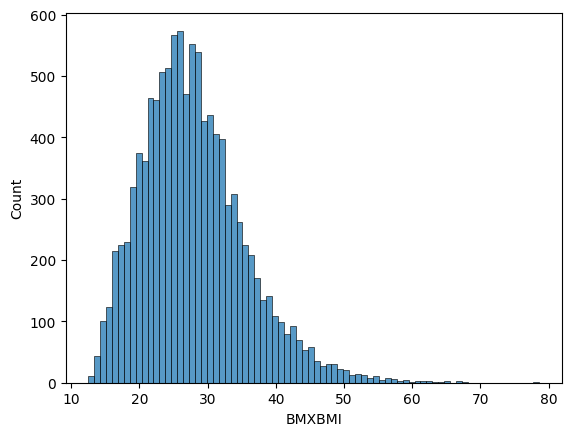

In [51]:
tmp4 = nhane[['BMXBMI',"BMXLEG",'BMXWAIST','BMXHT']].copy()
# tmp4.loc[tmp4['BMXBMI']==tmp4['BMXBMI'].max()]
tmp4.dropna(inplace=True)
sns.histplot(tmp4,x='BMXBMI')

(array([0, 1]), array([10685,   196]))

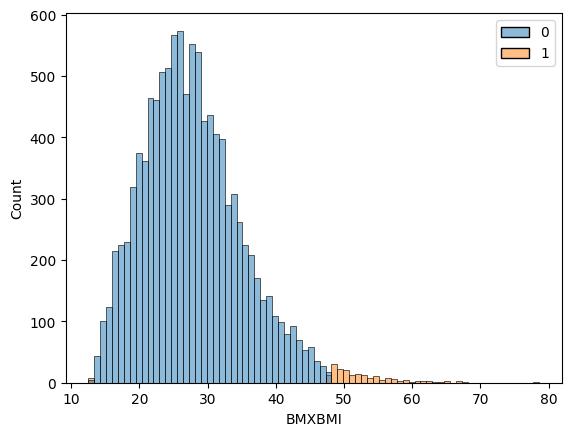

In [52]:
# tmp4.loc[tmp4['BMXBMI'] == tmp4['BMXBMI'].max(), 'BMXBMI']
# sns.histplot(tmp4,x='BMXBMI')

from pyod.models.kde import KDE
clf = KDE(contamination=0.018)
clf.fit(tmp4['BMXBMI'].to_numpy().reshape(-1,1))
y_train_pred = clf.labels_
sns.histplot(tmp4,x='BMXBMI',hue=y_train_pred)
np.unique(y_train_pred, return_counts=True)

In [53]:
nhane['BMDSTATS'].unique()

<StringArray>
[              'Complete data for age group',
                                         nan,
 'Partial:  Only height and weight obtained',
                'No body measures exam data',
                        'Other partial exam']
Length: 5, dtype: str